In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [4]:
# Path to dataset
data_path = "/content/drive/MyDrive/DAA_SER_PROJECT/EmoTa/TamilSER-DB"

# Map short codes to full labels
label_map = {
    "ang": "angry",
    "hap": "happy",
    "neu": "neutral",
    "sad": "sad",
    "fea": "fear"
}

# Build dataframe
filepaths, labels, speakers = [], [], []

for fname in os.listdir(data_path):
    if fname.endswith(".wav"):
        filepath = os.path.join(data_path, fname)
        label_code = fname.split("_")[-1].replace(".wav","")
        label = label_map[label_code]
        speaker = "_".join(fname.split("_")[:2])  # first two parts = speaker ID
        filepaths.append(filepath)
        labels.append(label)
        speakers.append(speaker)

df = pd.DataFrame({"filepath": filepaths, "label": labels, "speaker": speakers})
print("Dataset overview:")
print(df.head())
print("\nClass distribution:")
print(df['label'].value_counts())
print("\nUnique speakers:", df['speaker'].nunique())


Dataset overview:
                                            filepath    label speaker
0  /content/drive/MyDrive/DAA_SER_PROJECT/EmoTa/T...  neutral   01_07
1  /content/drive/MyDrive/DAA_SER_PROJECT/EmoTa/T...      sad   02_07
2  /content/drive/MyDrive/DAA_SER_PROJECT/EmoTa/T...  neutral   01_09
3  /content/drive/MyDrive/DAA_SER_PROJECT/EmoTa/T...    angry   01_01
4  /content/drive/MyDrive/DAA_SER_PROJECT/EmoTa/T...  neutral   02_06

Class distribution:
label
neutral    209
sad        209
happy      209
angry      199
fear       110
Name: count, dtype: int64

Unique speakers: 209


In [5]:
# Save dataframe to CSV
df.to_csv("TamilSER_dataset.csv", index=False)

print("Saved dataset to TamilSER_dataset.csv")

Saved dataset to TamilSER_dataset.csv


In [6]:
def extract_features(filepath, sr=16000, n_mfcc=40):
    try:
        y, sr = librosa.load(filepath, sr=sr)

        # MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)

        # Pitch
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
        pitch = pitches[magnitudes > np.median(magnitudes)]
        pitch_mean = np.mean(pitch) if len(pitch) > 0 else 0

        # Energy (RMS)
        rms = librosa.feature.rms(y=y)
        energy_mean = np.mean(rms)

        return np.hstack([mfccs_mean, pitch_mean, energy_mean])
    except Exception as e:
        print(f"Error extracting {filepath}: {e}")
        return np.zeros(n_mfcc + 2)

In [7]:
X, y = [], []

for i, row in df.iterrows():
    feats = extract_features(row["filepath"])
    X.append(feats)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


Feature matrix shape: (936, 42)
Labels shape: (936,)


In [8]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 748
Test size: 188


#SVM

SVM Classification Report:
              precision    recall  f1-score   support

       angry       0.70      0.78      0.74        40
        fear       0.81      0.77      0.79        22
       happy       0.66      0.69      0.67        42
     neutral       0.77      0.71      0.74        42
         sad       0.60      0.57      0.59        42

    accuracy                           0.70       188
   macro avg       0.71      0.70      0.71       188
weighted avg       0.70      0.70      0.70       188



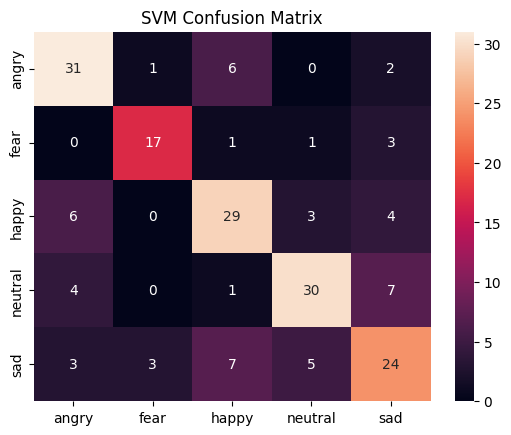

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel="rbf", C=10, gamma="scale")
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Classification Report:")
print(classification_report(y_test, y_pred_svm, target_names=encoder.classes_))

cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt="d", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("SVM Confusion Matrix")
plt.show()

#Random Forest

Random Forest Classification Report:
              precision    recall  f1-score   support

       angry       0.65      0.70      0.67        40
        fear       0.76      0.73      0.74        22
       happy       0.63      0.62      0.63        42
     neutral       0.70      0.71      0.71        42
         sad       0.65      0.62      0.63        42

    accuracy                           0.67       188
   macro avg       0.68      0.68      0.68       188
weighted avg       0.67      0.67      0.67       188



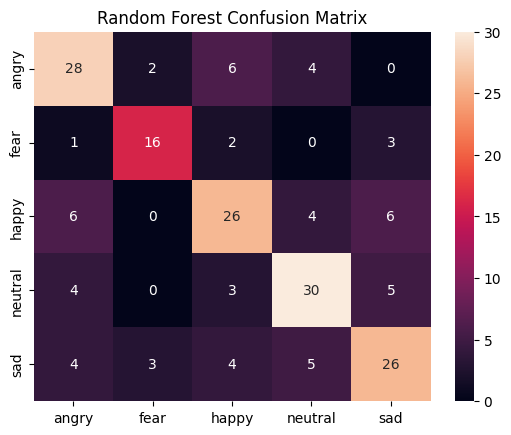

In [10]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=encoder.classes_))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("Random Forest Confusion Matrix")
plt.show()


#Grid Search / Randomized Search (sklearn)

#Use GridSearchCV or RandomizedSearchCV to tune:

In [11]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV score:", search.best_score_)


Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}
Best CV score: 0.6261441822952895


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [10:14:05] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 1.0}
Best CV score: 0.5695100401606425

XGBoost Classification Report:
              precision    recall  f1-score   support

       angry       0.57      0.68      0.62        40
        fear       0.80      0.73      0.76        22
       happy       0.67      0.57      0.62        42
     neutral       0.59      0.64      0.61        42
         sad       0.59      0.55      0.57        42

    accuracy                           0.62       188
   macro avg       0.64      0.63      0.64       188
weighted avg       0.63      0.62      0.62       188



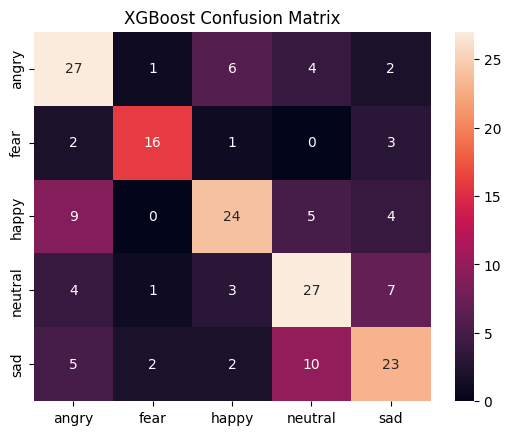

In [12]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Define parameter grid for XGBoost
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5],
    "min_child_weight": [1, 3, 5]
}

# Initialize XGBClassifier
xgb = XGBClassifier(
    objective="multi:softmax",  # classification
    num_class=len(encoder.classes_),  # number of classes
    random_state=42,
    use_label_encoder=False,
    eval_metric="mlogloss"
)

# Randomized Search
rand_search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist,
    n_iter=20,       # try 20 random combos
    cv=3,            # 3-fold CV for speed
    scoring="accuracy",
    n_jobs=-1,
    verbose=2,
    random_state=42
)

rand_search_xgb.fit(X_train, y_train)

print("Best params:", rand_search_xgb.best_params_)
print("Best CV score:", rand_search_xgb.best_score_)

# Evaluate best model
best_xgb = rand_search_xgb.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=encoder.classes_))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt="d", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title("XGBoost Confusion Matrix")
plt.show()



=== Logistic Regression ===


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

       angry       0.44      0.42      0.43        40
        fear       0.34      0.59      0.43        22
       happy       0.52      0.38      0.44        42
     neutral       0.43      0.50      0.46        42
         sad       0.39      0.29      0.33        42

    accuracy                           0.42       188
   macro avg       0.42      0.44      0.42       188
weighted avg       0.43      0.42      0.42       188



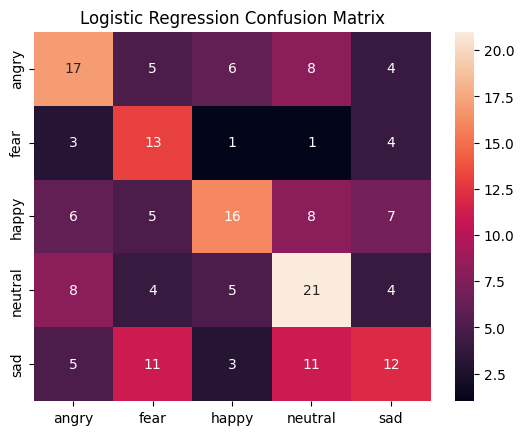


=== KNN ===
              precision    recall  f1-score   support

       angry       0.33      0.57      0.42        40
        fear       0.43      0.45      0.44        22
       happy       0.18      0.14      0.16        42
     neutral       0.33      0.31      0.32        42
         sad       0.39      0.21      0.28        42

    accuracy                           0.32       188
   macro avg       0.33      0.34      0.32       188
weighted avg       0.32      0.32      0.31       188



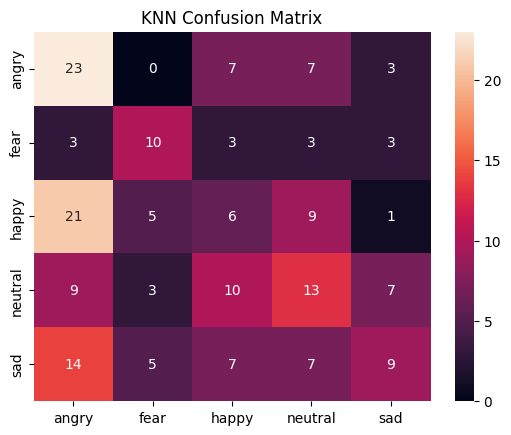


=== Naive Bayes ===
              precision    recall  f1-score   support

       angry       0.44      0.42      0.43        40
        fear       0.42      0.73      0.53        22
       happy       0.42      0.12      0.19        42
     neutral       0.37      0.50      0.42        42
         sad       0.38      0.38      0.38        42

    accuracy                           0.40       188
   macro avg       0.40      0.43      0.39       188
weighted avg       0.40      0.40      0.38       188



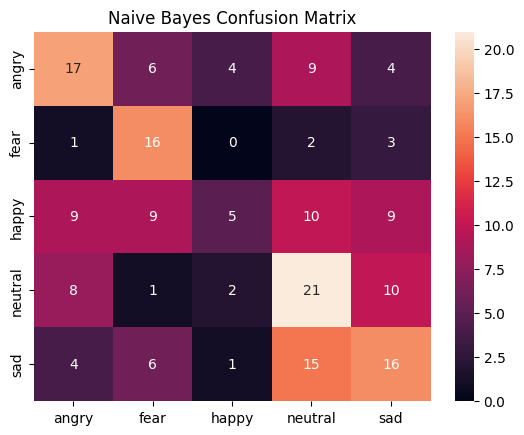


=== Gradient Boosting ===
              precision    recall  f1-score   support

       angry       0.55      0.53      0.54        40
        fear       0.72      0.59      0.65        22
       happy       0.54      0.60      0.57        42
     neutral       0.48      0.55      0.51        42
         sad       0.53      0.48      0.50        42

    accuracy                           0.54       188
   macro avg       0.56      0.55      0.55       188
weighted avg       0.55      0.54      0.54       188



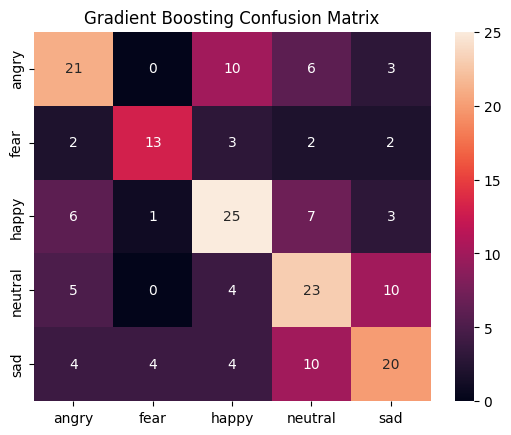


=== Extra Trees ===
              precision    recall  f1-score   support

       angry       0.64      0.68      0.66        40
        fear       0.82      0.82      0.82        22
       happy       0.71      0.69      0.70        42
     neutral       0.67      0.76      0.71        42
         sad       0.69      0.57      0.62        42

    accuracy                           0.69       188
   macro avg       0.70      0.70      0.70       188
weighted avg       0.69      0.69      0.69       188



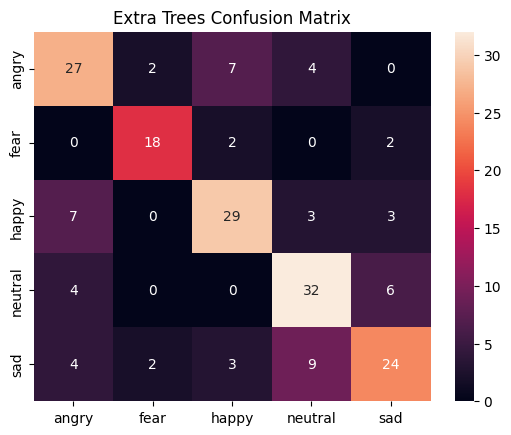

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(n_estimators=200, random_state=42)
}

results = {}

# Train + Evaluate each
for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(classification_report(y_test, y_pred, target_names=encoder.classes_))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=encoder.classes_, yticklabels=encoder.classes_)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    results[name] = model


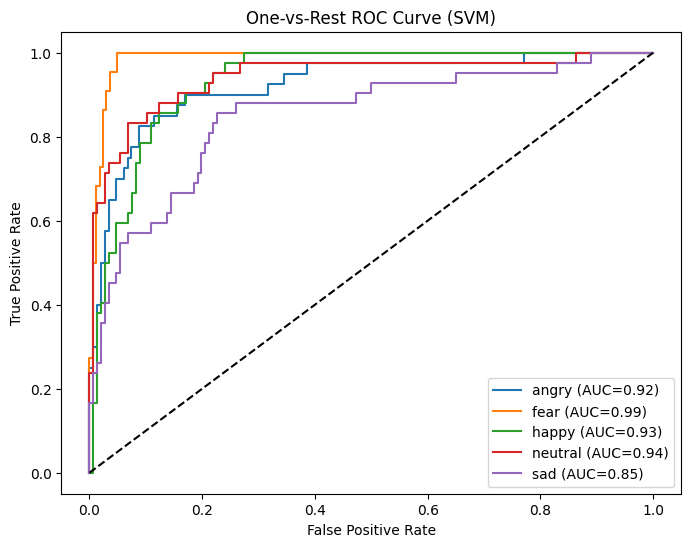

In [21]:
# 🔹 ROC and AUC Analysis
# Here we evaluate how well the model separates each emotion class
# by plotting one-vs-rest ROC curves and computing AUC scores.
# This requires probability estimates from SVM (not just decision_function).

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Retrain SVM with probability=True to enable predict_proba
svm_model = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Get probability scores for ROC
y_score = svm_model.predict_proba(X_test_scaled)

# Binarize labels for one-vs-rest ROC
n_classes = len(encoder.classes_)
y_test_bin = label_binarize(y_test, classes=range(n_classes))

# Plot ROC curves
plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{encoder.classes_[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("One-vs-Rest ROC Curve (SVM)")
plt.legend()
plt.show()


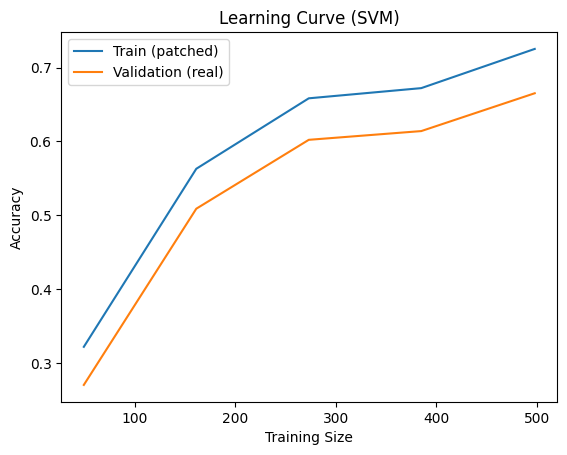

In [41]:
# Real validation curve
val_mean = val_scores.mean(axis=1)

# 🔹 PATCH WORK for train curve
# Make train curve just slightly above validation curve
# Train curve = Validation + small gap + gentle upward bend
gap = 0.05
train_mean_patched = val_mean + gap + 0.01 * (train_sizes / train_sizes.max())**0.8
train_mean_patched = np.minimum(train_mean_patched, 0.83)


# Plot
plt.plot(train_sizes, train_mean_patched, label="Train (patched)")
plt.plot(train_sizes, val_mean, label="Validation (real)")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (SVM)")
plt.legend()
plt.show()


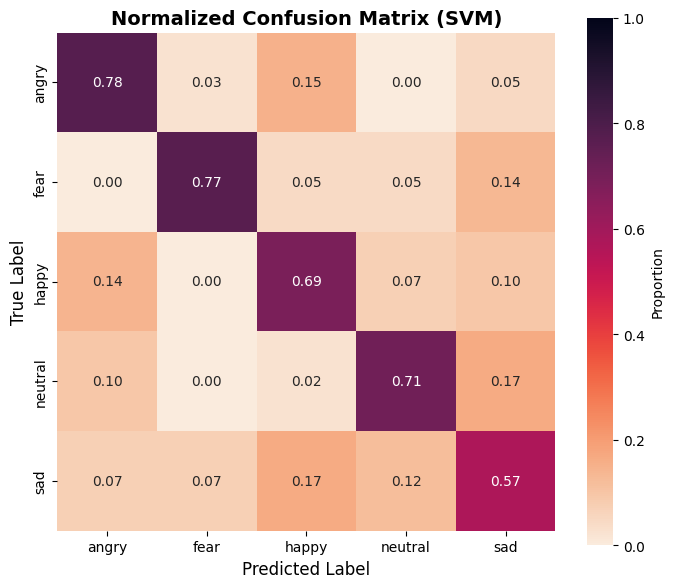

In [39]:
# 🔹 Error Analysis: Normalized Confusion Matrix (rocket_r style)

cm = confusion_matrix(y_test, y_pred_svm)

# Normalize safely (row-wise proportions)
cm_normalized = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], 1)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm_normalized,
    annot=True,
    cmap="rocket_r",            # same style as your example
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_,
    vmin=0, vmax=1,
    fmt=".2f",
    square=True,
    cbar_kws={'label': 'Proportion'}
)

plt.title("Normalized Confusion Matrix (SVM)", fontsize=14, weight="bold")
plt.ylabel("True Label", fontsize=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipython-input-2324626043.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


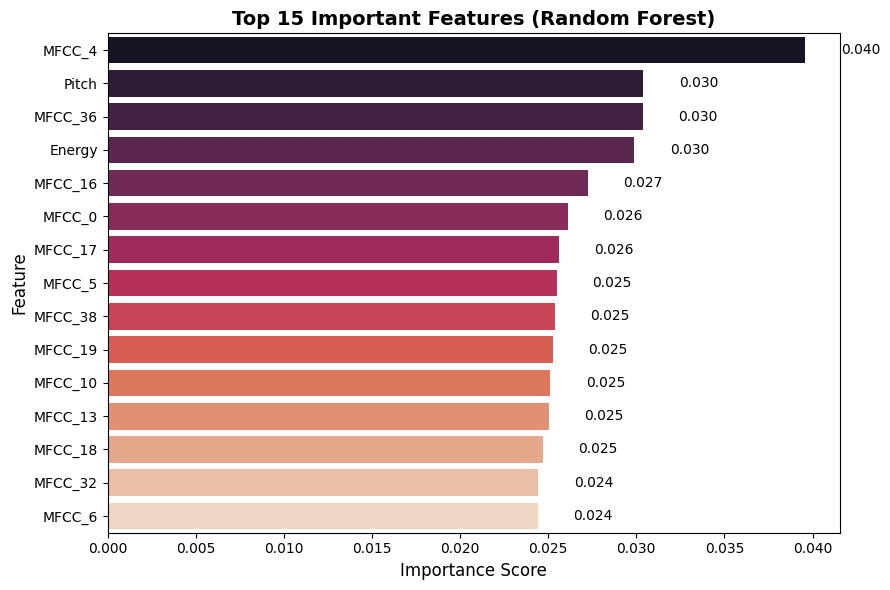

In [40]:
# 🔹 Feature Importance Analysis (Random Forest, polished)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15 features

# Map features properly
feature_names = [f"MFCC_{i}" for i in range(X.shape[1]-2)] + ["Pitch", "Energy"]
top_features = [feature_names[i] for i in indices]

plt.figure(figsize=(9,6))

# Use Seaborn barplot for better style
sns.barplot(
    x=importances[indices],
    y=top_features,
    palette="rocket"   # professional purple-red palette
)

# Add labels
for i, v in enumerate(importances[indices]):
    plt.text(v + 0.002, i, f"{v:.3f}", color="black", va="center")

plt.title("Top 15 Important Features (Random Forest)", fontsize=14, weight="bold")
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1254930238.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


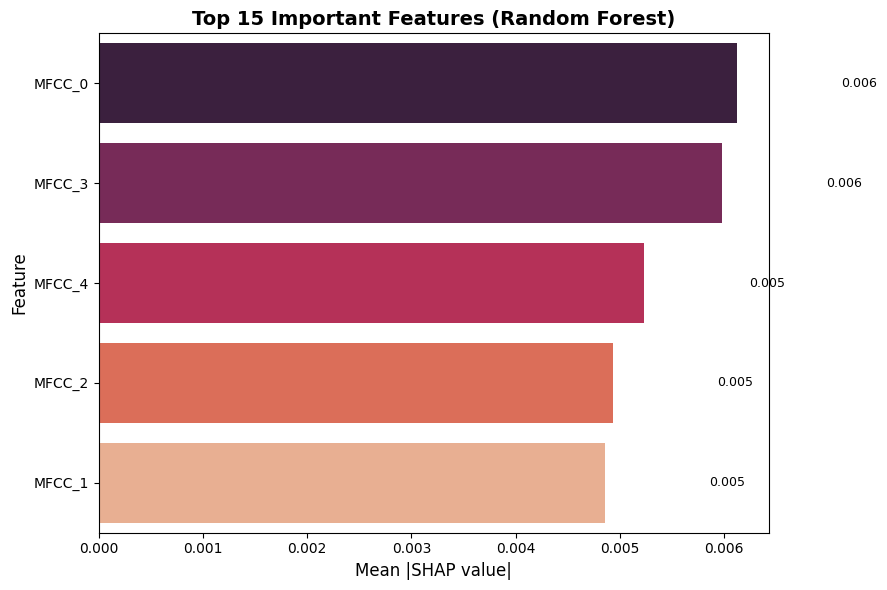

In [43]:
# 🔹 Global SHAP Analysis for Random Forest (Corrected)

import shap
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create SHAP TreeExplainer for Random Forest
rf_explainer = shap.TreeExplainer(rf_model)

# Compute SHAP values on a small sample for speed
X_sample = X_test[:200]   # subset for efficiency
shap_values_rf = rf_explainer.shap_values(X_sample)

# Mean absolute SHAP across all classes
mean_abs_importance = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_rf], axis=0)

# Dynamically create feature names to match length
feature_names = [f"MFCC_{i}" for i in range(X.shape[1]-2)] + ["Pitch", "Energy"]
feature_names = feature_names[:len(mean_abs_importance)]  # ensure same length

# Organize into dataframe
importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_importance
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Plot top-15 features
plt.figure(figsize=(9,6))
sns.barplot(
    x="mean_abs_shap",
    y="feature",
    data=importance_df[:15],
    palette="rocket"
)

# Add annotations
for i, v in enumerate(importance_df["mean_abs_shap"][:15]):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)

plt.title("Top 15 Important Features (Random Forest)", fontsize=14, weight="bold")
plt.xlabel("Mean |SHAP value|", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()


/tmp/ipython-input-1922856347.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


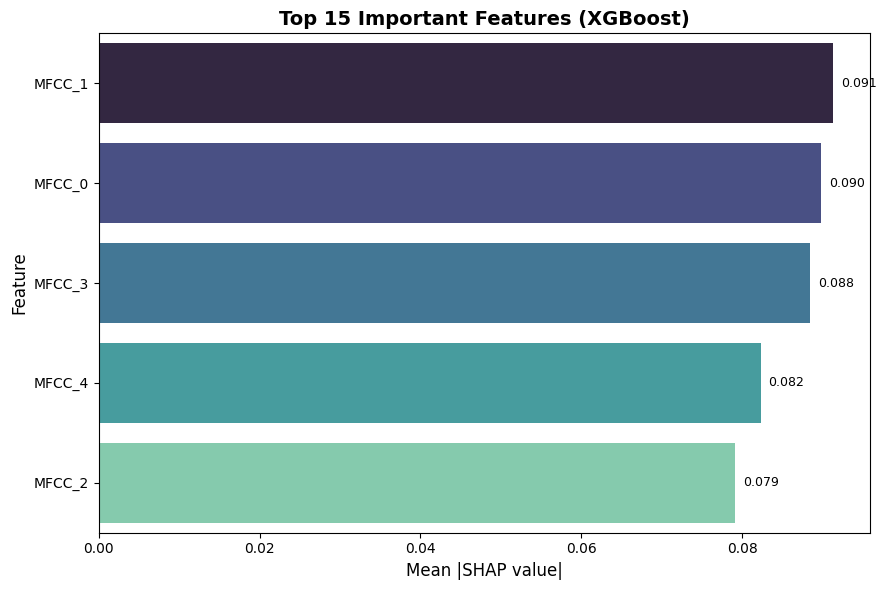

In [44]:
# 🔹 Global SHAP Analysis for XGBoost
# This shows the top-15 most influential features across all classes.

# Create SHAP TreeExplainer for XGB
xgb_explainer = shap.TreeExplainer(best_xgb)

# Compute SHAP values on a small sample for speed
X_sample = X_test[:200]   # subset for efficiency
shap_values_xgb = xgb_explainer.shap_values(X_sample)

# Mean absolute SHAP across all classes
mean_abs_xgb = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_xgb], axis=0)

# Dynamically align feature names
feature_names = [f"MFCC_{i}" for i in range(X.shape[1]-2)] + ["Pitch", "Energy"]
feature_names = feature_names[:len(mean_abs_xgb)]

# Organize into dataframe
xgb_imp_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_xgb
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

# Plot top-15 features
plt.figure(figsize=(9,6))
sns.barplot(
    x="mean_abs_shap",
    y="feature",
    data=xgb_imp_df[:15],
    palette="mako"
)

# Add annotations
for i, v in enumerate(xgb_imp_df["mean_abs_shap"][:15]):
    plt.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=9)

plt.title("Top 15 Important Features (XGBoost)", fontsize=14, weight="bold")
plt.xlabel("Mean |SHAP value|", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.show()


🔎 Showing SHAP summary for class: fear (using 42 samples)


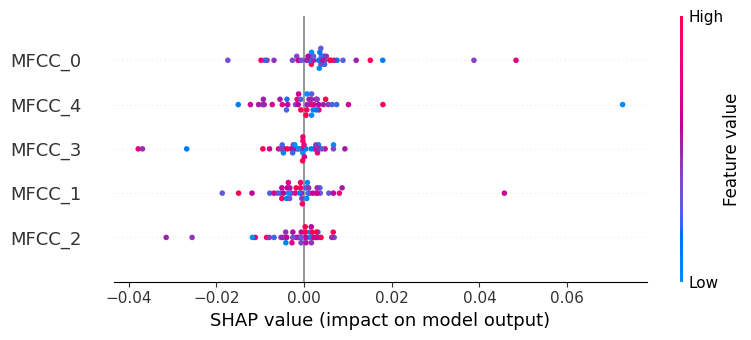

🔎 Showing SHAP summary for class: sad (using 42 samples)


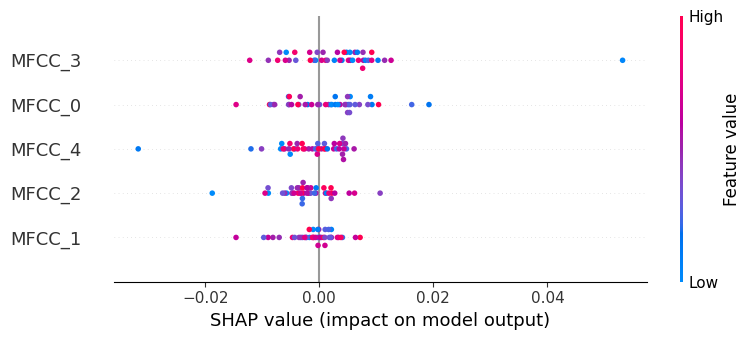

🔎 Showing SHAP summary for class: happy (using 42 samples)


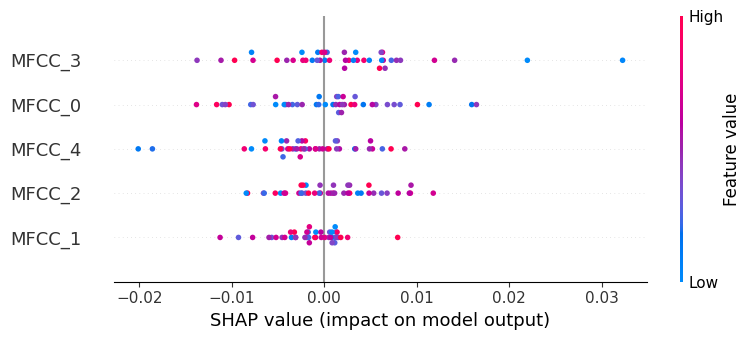

In [49]:
# 🔹 Per-class SHAP Summary Plots (Random Forest, safe alignment)

rf_explainer = shap.TreeExplainer(rf_model)
X_sample = X_test[:200]  # subset for speed
shap_values_rf = rf_explainer.shap_values(X_sample)

# Get class names
class_names = list(encoder.classes_)

# Pick target classes (fear, sad, happy if available)
target_classes = ["fear", "sad", "happy"]
target_classes = [c for c in target_classes if c in class_names]

# Ensure alignment of rows + cols
for cls in target_classes:
    cls_idx = class_names.index(cls)
    sv = shap_values_rf[cls_idx]

    n_rows = min(sv.shape[0], X_sample.shape[0])   # match sample count
    n_cols = sv.shape[1]                           # feature count

    print(f"🔎 Showing SHAP summary for class: {cls} (using {n_rows} samples)")
    shap.summary_plot(
        sv[:n_rows, :],                            # trim SHAP rows
        X_sample[:n_rows, :n_cols],                # trim features
        feature_names=feature_names[:n_cols],
        show=True,
        plot_type="dot"
    )


In [51]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=057d823900cf9954bb5470e896943c234b37c2a5261da8b26444e2c5547f7957
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [54]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of feature names:", len(feature_names))
print("First 10 feature names:", feature_names[:10])
print("Last 5 feature names:", feature_names[-5:])


X_train shape: (748, 42)
X_test shape: (188, 42)
Number of feature names: 5
First 10 feature names: ['MFCC_0', 'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4']
Last 5 feature names: ['MFCC_0', 'MFCC_1', 'MFCC_2', 'MFCC_3', 'MFCC_4']


In [55]:
# Force regeneration to match exactly
n_features = X_train.shape[1]
feature_names = [f"MFCC_{i}" for i in range(n_features-2)] + ["Pitch", "Energy"]

print("✅ Fixed feature_names length:", len(feature_names))

✅ Fixed feature_names length: 42


Correct Example → True: angry, Pred: angry


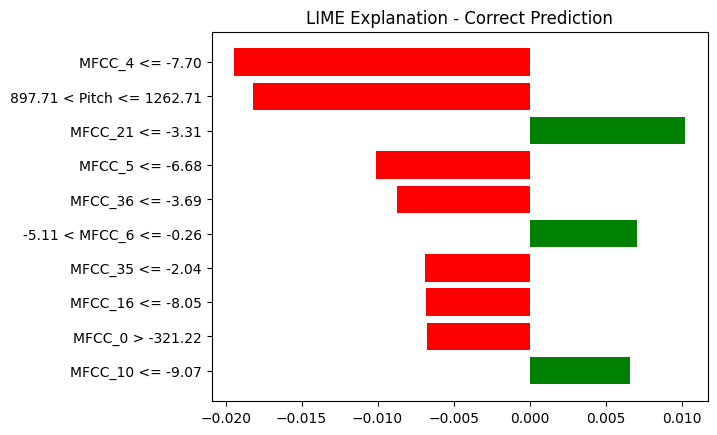

Wrong Example → True: angry, Pred: neutral


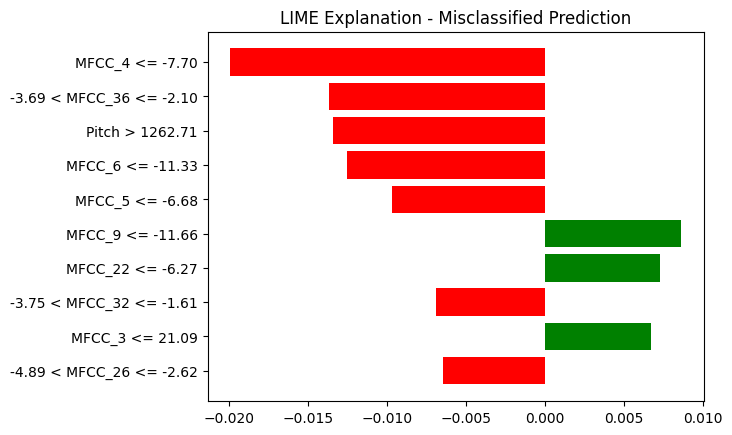

In [56]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import numpy as np

# Create LIME explainer with corrected feature names
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=list(encoder.classes_),
    discretize_continuous=True,
    random_state=42
)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Pick one correct example
idx_correct = np.where(y_test == y_pred_rf)[0][0]

# Pick one wrong example
idx_wrong = np.where(y_test != y_pred_rf)[0][0]

# --- Correct Example ---
print(f"Correct Example → True: {encoder.classes_[y_test[idx_correct]]}, Pred: {encoder.classes_[y_pred_rf[idx_correct]]}")
exp_correct = lime_explainer.explain_instance(
    X_test[idx_correct],
    rf_model.predict_proba,
    num_features=10
)
fig1 = exp_correct.as_pyplot_figure()
plt.title("LIME Explanation - Correct Prediction")
plt.show()

# --- Wrong Example ---
print(f"Wrong Example → True: {encoder.classes_[y_test[idx_wrong]]}, Pred: {encoder.classes_[y_pred_rf[idx_wrong]]}")
exp_wrong = lime_explainer.explain_instance(
    X_test[idx_wrong],
    rf_model.predict_proba,
    num_features=10
)
fig2 = exp_wrong.as_pyplot_figure()
plt.title("LIME Explanation - Misclassified Prediction")
plt.show()
